# Pressure-Velocity Coupled 2D Fixed-Bed Reactor

## Background

This notebook compares a one-dimensional constant-pressure reference model with a two-dimensional tube model for the gas-phase reaction

$$
A \rightarrow B + C.
$$

The inlet conditions and chemistry follow the fixed-bed reactor exercise: 1 bar, 293 K, and an inlet interstitial velocity of 2 m/s. The 1D reference is useful because it shows the expected axial conversion, temperature rise, and velocity increase when pressure is fixed. The 2D model keeps the same reaction but solves concentrations, temperature, and pressure in one coupled residual.

The purpose of the notebook is to show how pressure-velocity coupling fits into the same finite-volume residual structure as species and heat balances. The pressure field drives a parabolic axial velocity profile, wall cooling creates radial temperature and concentration profiles, and the pressure row enforces total molar continuity.


In [94]:
from __future__ import annotations

from dataclasses import dataclass, field, replace
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    NumJac,
    construct_div,
    construct_grad,
    interp_cntr_to_stagg,
    interp_cntr_to_stagg_tvd,
    newton,
    non_uniform_grid,
)

## Governing Equations

The two-dimensional unknown field is

$$
\mathbf{u}(z,r) = \left(c_A, c_B, c_C, T, p\right)^T.
$$

For each species, the finite-volume balance is written in conservative form,

$$
\frac{c_i-c_i^n}{\Delta t}+
\nabla\cdot\left(c_i\mathbf{v} + \mathbf{J}_i\right) = \nu_i r,
\qquad \nu=(-1,1,1),
$$

with first-order kinetics

$$
r = k c_A,
\qquad
k = k_0 \exp\left(-\frac{E_a}{RT}\right).
$$

Species diffusion is written with mole-fraction gradients,

$$
\mathbf{J}_i = -D c_\mathrm{tot}\nabla y_i,
\qquad y_i = \frac{c_i}{\sum_j c_j}.
$$

This makes the outflow condition $\nabla y_i\cdot\mathbf{n}=0$ natural. At an inlet face the upwind convective flux uses the specified inlet composition.

The temperature equation uses a cell-centered volumetric heat capacity,

$$
\left(\sum_i c_i C_{p,i}\right)
\left[\frac{T-T^n}{\Delta t}+\mathbf{v}\cdot\nabla T\right]
- \nabla\cdot(\lambda\nabla T)
+ \Delta H_r r = 0.
$$

In the implementation the advective derivative is evaluated as

$$
\mathbf{v}\cdot\nabla T = \nabla\cdot(\mathbf{v}T)-T\nabla\cdot\mathbf{v}.
$$

This detail matters: putting velocity and heat capacity inside the divergence operator would add artificial heat sources when the gas expands or contracts. The $\mathbf{v}T$ face flux is evaluated with an upwind/TVD interpolation, so the temperature equation does not use a central-difference convective flux. Wall cooling is imposed with

$$
-\lambda \nabla T\cdot\mathbf{n} = h(T-T_\mathrm{cool}).
$$

The axial velocity is pressure driven with a parabolic profile,

$$
v_z = -K_z\,\phi(r)\frac{\partial p}{\partial z},
\qquad
\phi(r)=2\left[1-\left(\frac{r}{R}\right)^2\right],
\qquad
K_z=\frac{R^2}{8\mu}.
$$

A weak radial Darcy velocity is included,

$$
v_r = -K_r\frac{\partial p}{\partial r}.
$$

The pressure equation is a total molar continuity balance evaluated with the ideal-gas total concentration,

$$
\frac{c_{\mathrm{tot},p}-c_{\mathrm{tot},p}^n}{\Delta t}
+\nabla\cdot\left(c_{\mathrm{tot},p}\mathbf{v}+\sum_i\mathbf{J}_{i,p}\right)
= \sum_i\nu_i r_p,
\qquad
c_{\mathrm{tot},p}=\frac{p}{RT}.
$$

The ideal gas law therefore enters the pressure row through the density used in total continuity. It is not used as a separate algebraic pressure equation.

The nonlinear solve uses backward Euler with a large time step. This is close to a steady solve, but the accumulation terms give nearly stagnant cells an inventory and help remove singular modes. The Arrhenius factor is evaluated from the previous time level and held fixed during each Newton solve. The reaction remains implicit in $c_A$, while the strong temperature dependence of $k$ is kept out of the Jacobian for robustness.


## Parameters and 1D Reference

The reference model uses molar flows per cross-sectional area, $F_i=c_i u$, and temperature. At constant pressure,

$$
c_\mathrm{tot}=\frac{P}{RT}, \qquad c_i = y_i c_\mathrm{tot}.
$$

This is the same variable-velocity constant-pressure formulation used in the fixed-bed exercise.


In [95]:
param = {
    "velocity_in": 2.0,
    "length": 0.5,
    "temperature_in": 293.0,
    "temperature_ref": 293.0,
    "pressure": 101_325.0,
    "x_in": np.array([1.0, 0.0, 0.0]),
    "k0": 1.0e9,
    "activation_energy": 50.0e3,
    "r_gas": 8.314,
    "reaction_enthalpy": -15.0e3,
    "heat_capacity": np.array([100.0, 60.0, 40.0]),
}

stoich = np.array([-1.0, 1.0, 1.0])


def reaction_rate(c_a, temperature, p=param):
    return p["k0"] * np.exp(-p["activation_energy"] / (p["r_gas"] * temperature)) * c_a


def fixed_bed_reference_rhs(z, state, p=param):
    flows = state[:3]
    temperature = state[3]
    total_flow = np.sum(flows)
    c_total = p["pressure"] / (p["r_gas"] * temperature)
    mole_fraction = flows / total_flow
    c_a = mole_fraction[0] * c_total
    rate = reaction_rate(c_a, temperature, p)
    flow_heat_capacity = np.dot(flows, p["heat_capacity"])
    dflows_dz = stoich * rate
    sensible_source = (temperature - p["temperature_ref"]) * np.dot(dflows_dz, p["heat_capacity"])
    dtemperature_dz = ((-p["reaction_enthalpy"]) * rate - sensible_source) / flow_heat_capacity
    return np.r_[dflows_dz, dtemperature_dz]

c_total_in = param["pressure"] / (param["r_gas"] * param["temperature_in"])
flow_in = param["velocity_in"] * c_total_in * param["x_in"]
reference_initial = np.r_[flow_in, param["temperature_in"]]
reference_solution = solve_ivp(
    fixed_bed_reference_rhs,
    (0.0, param["length"]),
    reference_initial,
    method="LSODA",
    dense_output=True,
    rtol=1.0e-10,
    atol=1.0e-12,
)

z_plot = np.linspace(0.0, param["length"], 300)
reference_state = reference_solution.sol(z_plot)
reference_flows = reference_state[:3].T
reference_temperature = reference_state[3]
reference_total_flow = np.sum(reference_flows, axis=1)
reference_c_total = param["pressure"] / (param["r_gas"] * reference_temperature)
reference_mole_fraction = reference_flows / reference_total_flow[:, None]
reference_concentration = reference_mole_fraction * reference_c_total[:, None]
reference_velocity = reference_total_flow / reference_c_total

reference_summary = pd.Series({
    "outlet conversion A": 1.0 - reference_flows[-1, 0] / reference_flows[0, 0],
    "outlet temperature [K]": reference_temperature[-1],
    "outlet velocity [m/s]": reference_velocity[-1],
})
reference_summary

outlet conversion A         1.000000
outlet temperature [K]    443.000000
outlet velocity [m/s]       6.047782
dtype: float64

## 2D Model Settings

The 2D model uses the same inlet state and chemistry as the reference calculation. The unknown array has shape `(n_z, n_r, 5)` and stores

```text
[c_A, c_B, c_C, T, p]
```

The radial grid is refined near the cooled wall. The pressure drop is chosen from the 1D reference mean velocity and Poiseuille scaling, so the inlet velocity scale is comparable to the exercise value of 2 m/s.


In [96]:
@dataclass
class TubeConfig:
    n_z: int = 100
    n_r: int = 30
    length: float = param["length"]
    radius: float = 6.0e-3
    pressure_in: float = param["pressure"]
    pressure_out: float = param["pressure"]
    temperature_in: float = param["temperature_in"]
    temperature_ref: float = param["temperature_ref"]
    coolant_temperature: float = 293.0
    inlet_velocity: float = param["velocity_in"]
    r_gas: float = param["r_gas"]
    viscosity: float = 1.85e-5
    radial_pressure_mobility: float = 8.0e-7
    d_ax: float = 0.0
    d_rad: float = 5.0e-5
    thermal_conductivity: float = 0.035
    heat_transfer_coefficient: float = 20.0
    k0: float = param["k0"]
    activation_energy: float = param["activation_energy"]
    reaction_enthalpy: float = param["reaction_enthalpy"]
    heat_capacity: np.ndarray = field(default_factory=lambda: param["heat_capacity"].copy())
    inlet_mole_fraction: np.ndarray = field(default_factory=lambda: param["x_in"].copy())
    tol: float = 1.0e-6
    maxfev: int = 40
    time_step: float = 0.1

    @property
    def c_total_in(self):
        return self.pressure_in / (self.r_gas * self.temperature_in)

    @property
    def concentration_in(self):
        return self.inlet_mole_fraction * self.c_total_in


mean_velocity_reference = np.trapezoid(reference_velocity, z_plot) / param["length"]


def pressure_drop_for(config, velocity=mean_velocity_reference):
    return 8.0 * config.viscosity * config.length * velocity / config.radius**2


def config_with_pressure_drop(**kwargs):
    config = TubeConfig(**kwargs)
    return replace(config, pressure_out=config.pressure_in - pressure_drop_for(config))


cfg = config_with_pressure_drop()

pd.Series(
    {
        "n_z": cfg.n_z,
        "n_r": cfg.n_r,
        "radius [mm]": 1e3 * cfg.radius,
        "wall HTC [W/m2/K]": cfg.heat_transfer_coefficient,
        "radial diffusivity [m2/s]": cfg.d_rad,
        "thermal conductivity [W/m/K]": cfg.thermal_conductivity,
        "pressure drop [Pa]": cfg.pressure_in - cfg.pressure_out,
        "time step [s]": cfg.time_step,
    },
    name="2D model settings",
)


n_z                             100.000000
n_r                              30.000000
radius [mm]                       6.000000
wall HTC [W/m2/K]                20.000000
radial diffusivity [m2/s]         0.000050
thermal conductivity [W/m/K]      0.035000
pressure drop [Pa]                8.849386
time step [s]                     0.100000
Name: 2D model settings, dtype: float64

## PyMRM Implementation

The model follows the class-based PyMRM pattern: build the grid and constant operators once, evaluate all coupled physics in `residual(...)`, keep spatial axes first and the field axis last, and do all plotting after the solve.

The radial grid is refined toward the wall with `non_uniform_grid(...)`, because wall cooling and radial diffusion create the steepest gradients near the boundary.

In [97]:
class PressureVelocityTube2D:
    n_species = 3
    i_t = n_species
    i_p = n_species + 1

    def __init__(self, cfg: TubeConfig):
        self.cfg = cfg
        self.shape = (cfg.n_z, cfg.n_r, self.n_species + 2)
        self.field_shape = (cfg.n_z, cfg.n_r)
        self._build_grid()
        self._build_operators()
        self._build_scaling()
        self.u0 = self.initial_state_from_reference()
        self.u_old = self.u0.copy()
        self.numjac = NumJac(self.shape, axes_diagonals=[0, 1], axes_blocks=[-1])

    def _build_grid(self):
        cfg = self.cfg
        self.z_f = np.linspace(0.0, cfg.length, cfg.n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.r_f = non_uniform_grid(0.0, cfg.radius, cfg.n_r + 1, 0.2 * cfg.radius, 0.85)
        self.r_c = 0.5 * (self.r_f[:-1] + self.r_f[1:])      
        self.axial_pressure_mobility = cfg.radius**2 / (8.0 * cfg.viscosity)
        self.velocity_profile = 2.0*(1.0 - (self.r_c / cfg.radius)**2)
        #self.velocity_profile = np.ones_like(self.r_c)
        dr_sq = np.diff(self.r_f**2)
        self.cup_weights = dr_sq*self.velocity_profile
        self.cup_weights /= np.sum(self.cup_weights)
        self.area_weights = dr_sq/(self.r_f[-1]**2)

    def _build_operators(self):
        cfg = self.cfg
        no_flux = {"a": 1.0, "b": 0.0, "d": 0.0}
        self.div_z = construct_div(self.field_shape, self.z_f, nu=0, axis=0)
        self.div_r = construct_div(self.field_shape, self.r_f, nu=1, axis=1)
        self.bc_z_p = (
            {"a": 0.0, "b": 1.0, "d": cfg.pressure_in},
            {"a": 0.0, "b": 1.0, "d": cfg.pressure_out},
        )
        self.grad_z_p, self.grad_z_p_bc = construct_grad(self.field_shape, self.z_f, self.z_c, bc=self.bc_z_p, axis=0)
        self.grad_r_p, self.grad_r_p_bc = construct_grad(self.field_shape, self.r_f, self.r_c, bc=(no_flux, no_flux), axis=1)
        self.grad_r_y, self.grad_r_y_bc = construct_grad(self.field_shape, self.r_f, self.r_c, bc=(no_flux, no_flux), axis=1)
        wall_temperature_bc = (
            no_flux,
            {
                "a": 1.0,
                "b": cfg.heat_transfer_coefficient / cfg.thermal_conductivity,
                "d": cfg.heat_transfer_coefficient * cfg.coolant_temperature / cfg.thermal_conductivity,
            },
        )
        self.grad_r_t, self.grad_r_t_bc = construct_grad(self.field_shape, self.r_f, self.r_c, bc=wall_temperature_bc, axis=1)

    def _build_scaling(self):
        cfg = self.cfg
        self.c_ref = cfg.c_total_in
        self.t_ref = cfg.temperature_in
        self.p_ref = cfg.pressure_in
        self.dp_ref = max(abs(cfg.pressure_in - cfg.pressure_out), 1.0)
        self.u_ref = cfg.inlet_velocity
        species_scale = self.c_ref * self.u_ref / cfg.length + cfg.d_rad * self.c_ref / cfg.radius**2
        heat_capacity_scale = self.c_ref * np.mean(cfg.heat_capacity)
        temperature_scale = heat_capacity_scale * self.t_ref * self.u_ref / cfg.length
        pressure_scale = species_scale
        self.state_offset = np.array([0.0, 0.0, 0.0, 0.0, self.p_ref]).reshape(1, 1, 5)
        self.state_scale = np.array([self.c_ref, self.c_ref, self.c_ref, self.t_ref, self.dp_ref]).reshape(1, 1, 5)
        self.residual_scale = (1.0 / np.array([species_scale, species_scale, species_scale, temperature_scale, pressure_scale])).reshape(1, 1, 5)

    def to_dimensionless(self, u_dim):
        return (u_dim.reshape(self.shape) - self.state_offset) / self.state_scale

    def to_dimensional(self, u_hat):
        return self.state_offset + u_hat.reshape(self.shape) * self.state_scale

    def initial_state_from_reference(self):
        cfg = self.cfg
        u = np.zeros(self.shape)
        ref = reference_solution.sol(self.z_c)
        flows = ref[:3].T
        temperature = ref[3]
        self.update_rate_constants(temperature)
        total_flow = np.sum(flows, axis=1)
        c_total = cfg.pressure_in / (cfg.r_gas * temperature)
        concentration = flows / total_flow[:, None] * c_total[:, None]
        u[..., :self.n_species] = concentration[:, None, :]
        u[..., self.i_t] = temperature[:, None]
        pressure_line = cfg.pressure_in + (cfg.pressure_out - cfg.pressure_in) * self.z_c / cfg.length
        u[..., self.i_p] = pressure_line[:, None]
        return u

    def fields(self, u):
        u = u.reshape(self.shape)
        return u[..., :self.n_species], u[..., self.i_t], u[..., self.i_p]

    def update_rate_constants(self, temperature):
        cfg = self.cfg
        self.k = cfg.k0 * np.exp(-cfg.activation_energy / (cfg.r_gas * temperature))
    
    def reaction_rate(self, c_a):
        return self.k * c_a

    def velocity_faces(self, pressure):
        cfg = self.cfg
        grad_p_z = np.asarray(self.grad_z_p @ pressure.ravel() + self.grad_z_p_bc.toarray().ravel()).reshape(cfg.n_z + 1, cfg.n_r)
        grad_p_r = np.asarray(self.grad_r_p @ pressure.ravel() + self.grad_r_p_bc.toarray().ravel()).reshape(cfg.n_z, cfg.n_r + 1)
        v_z = -self.axial_pressure_mobility * grad_p_z * self.velocity_profile.reshape(1, -1)
        v_r = -cfg.radial_pressure_mobility * grad_p_r
        return v_z, v_r

    def axial_bcs(self, inlet_value, outlet_value, v_z):
        left_is_inflow = (v_z[0, :] > 0.0).reshape(1, -1)
        right_is_inflow = (v_z[-1, :] < 0.0).reshape(1, -1)
        b_left = left_is_inflow.astype(float)
        b_right = right_is_inflow.astype(float)
        return (
            {"a": 1.0 - b_left, "b": b_left, "d": b_left * inlet_value},
            {"a": 1.0 - b_right, "b": b_right, "d": b_right * outlet_value},
        )

    def convective_flux(self, q, inlet_value, outlet_value, v_z, v_r):
        bc_z = self.axial_bcs(inlet_value, outlet_value, v_z)
        q_z, _ = interp_cntr_to_stagg_tvd(q, self.z_f, self.z_c, bc=bc_z, v=v_z, axis=0)
        q_r, _ = interp_cntr_to_stagg_tvd(q, self.r_f, self.r_c, bc=(None, None), v=v_r, axis=1)
        flux_z = (v_z * q_z).ravel()
        flux_r = (v_r * q_r).ravel()
        return flux_z, flux_r

    def species_flux(self, c_i, c_total, y_in, y_out, v_z, v_r):
        cfg = self.cfg
        inlet_c = y_in * cfg.c_total_in
        outlet_c = y_out * cfg.pressure_out / (cfg.r_gas * cfg.temperature_in)
        conv_z, conv_r = self.convective_flux(c_i, inlet_c, outlet_c, v_z, v_r)
        y_i = c_i / np.maximum(c_total, 1.0e-30)
        grad_z_y, grad_z_y_bc = construct_grad(
            self.field_shape,
            self.z_f,
            self.z_c,
            bc=self.axial_bcs(y_in, y_out, v_z),
            axis=0,
        )
        grad_y_z = grad_z_y @ y_i.ravel() + grad_z_y_bc.toarray().ravel()
        grad_y_r = self.grad_r_y @ y_i.ravel() + self.grad_r_y_bc.toarray().ravel()
        c_total_z = interp_cntr_to_stagg(c_total, self.z_f, self.z_c, axis=0)
        c_total_r = interp_cntr_to_stagg(c_total, self.r_f, self.r_c, axis=1)
        diff_z = -cfg.d_ax * c_total_z.ravel() * grad_y_z
        diff_r = -cfg.d_rad * c_total_r.ravel() * grad_y_r
        return conv_z + diff_z, conv_r + diff_r

    def species_residual(self, c_i, c_total, y_in, y_out, source_i, v_z, v_r):
        flux_z, flux_r = self.species_flux(c_i, c_total, y_in, y_out, v_z, v_r)
        div_flux = self.div_z @ flux_z + self.div_r @ flux_r
        return np.asarray(div_flux).reshape(self.field_shape) - source_i

    def temperature_residual(self, concentration, temperature, temperature_old, rate, v_z, v_r):
        cfg = self.cfg
        heat_capacity_vol = np.sum(concentration * cfg.heat_capacity.reshape(1, 1, 3), axis=-1)
        accumulation = heat_capacity_vol * (temperature - temperature_old) / cfg.time_step
        flux_t_z, flux_t_r = self.convective_flux(temperature, cfg.temperature_in, cfg.temperature_in, v_z, v_r)
        div_v_t = np.asarray(self.div_z @ flux_t_z + self.div_r @ flux_t_r).reshape(self.field_shape)
        div_v = np.asarray(self.div_z @ v_z.ravel() + self.div_r @ v_r.ravel()).reshape(self.field_shape)
        convective_transport = heat_capacity_vol * (div_v_t - temperature * div_v)

        grad_z_t, grad_z_t_bc = construct_grad(
            self.field_shape,
            self.z_f,
            self.z_c,
            bc=self.axial_bcs(cfg.temperature_in, cfg.temperature_in, v_z),
            axis=0,
        )
        grad_t_z = grad_z_t @ temperature.ravel() + grad_z_t_bc.toarray().ravel()
        grad_t_r = self.grad_r_t @ temperature.ravel() + self.grad_r_t_bc.toarray().ravel()
        heat_flux_z = -cfg.thermal_conductivity * grad_t_z
        heat_flux_r = -cfg.thermal_conductivity * grad_t_r
        div_heat_flux = np.asarray(self.div_z @ heat_flux_z + self.div_r @ heat_flux_r).reshape(self.field_shape)
        return accumulation + convective_transport + div_heat_flux + cfg.reaction_enthalpy * rate

    def residual_values_dimensional(self, u_dim, u_old_dim=None):
        cfg = self.cfg
        if u_old_dim is None:
            u_old_dim = self.u_old
        concentration, temperature, pressure = self.fields(u_dim)
        concentration_old, temperature_old, pressure_old = self.fields(u_old_dim)
        v_z, v_r = self.velocity_faces(pressure)
        c_total_raw = np.sum(concentration, axis=-1)
        y = concentration / np.maximum(c_total_raw[..., None], 1e-30)
        rate = self.reaction_rate(concentration[..., 0])
        source = stoich.reshape(1, 1, 3) * rate[..., None]
        g = np.zeros(self.shape)
        for i in range(3):
            accumulation = (concentration[..., i] - concentration_old[..., i]) / cfg.time_step
            g[..., i] = accumulation + self.species_residual(concentration[..., i], c_total_raw, cfg.inlet_mole_fraction[i], cfg.inlet_mole_fraction[i], source[..., i], v_z, v_r)
        g[..., self.i_t] = self.temperature_residual(concentration, temperature, temperature_old, rate, v_z, v_r)

        c_total_p = pressure / (cfg.r_gas * np.maximum(temperature, 150.0))
        c_total_p_old = pressure_old / (cfg.r_gas * np.maximum(temperature_old, 150.0))
        concentration_p = y * c_total_p[..., None]
        rate_p = self.reaction_rate(concentration_p[..., 0])
        source_p = stoich.reshape(1, 1, 3) * rate_p[..., None]
        pressure_residual = np.zeros(self.field_shape)
        for i in range(3):
            pressure_residual += self.species_residual(concentration_p[..., i], c_total_p, cfg.inlet_mole_fraction[i], cfg.inlet_mole_fraction[i], source_p[..., i], v_z, v_r)
        pressure_residual += (c_total_p - c_total_p_old) / cfg.time_step
        g[..., self.i_p] = pressure_residual
        return g

    def residual_values_scaled(self, u_hat, u_old=None):
        if u_old is None:
            u_old = self.u_old
        return self.residual_values_dimensional(self.to_dimensional(u_hat), u_old) * self.residual_scale

    def residual(self, u_hat, u_old=None):
        u_hat = u_hat.reshape(self.shape)
        g = self.residual_values_scaled(u_hat, u_old=u_old)
        g, jac = self.numjac(lambda x: self.residual_values_scaled(x, u_old=u_old), u_hat, f_value=g)
        return g.ravel(), jac

    def solve(self, u_old=None, n_timesteps=1):
        if u_old is None:
            u_old = self.u0
        u = u_old.copy()
        result = None

        for _ in range(n_timesteps):
            self.u_old = u.copy()
            self.update_rate_constants(self.u_old[..., self.i_t])
            x0 = self.to_dimensionless(u)
            result = newton(
                self.residual,
                x0,
                tol=self.cfg.tol,
                maxfev=self.cfg.maxfev,
                solver="spsolve",
            )
            self.u_hat = result.x.reshape(self.shape)
            u = self.to_dimensional(self.u_hat)
            if not result.success:
                break

        self.u = u
        final_residual = self.residual_values_scaled(self.u_hat).ravel()
        self.result = SimpleNamespace(
            success=result.success,
            message=result.message,
            nit=result.nit,
            fun=final_residual,
            x=self.u,
        )
        return self.result

    def area_average(self, field):
        return np.sum(field * self.area_weights.reshape(1, -1), axis=1)

    def cup_average(self, field):
        return np.sum(field * self.cup_weights.reshape(1, -1), axis=1)

    def solution_profiles(self):
        concentration, temperature, pressure = self.fields(self.u)
        v_z, v_r = self.velocity_faces(pressure)
        c_avg = np.stack([self.cup_average(concentration[..., i]) for i in range(3)], axis=-1)
        t_avg = self.cup_average(temperature)
        p_avg = self.area_average(pressure)
        vz_avg = self.area_average(v_z)
        vz_avg = 0.5*(vz_avg[:-1] + vz_avg[1:])
        return concentration, temperature, pressure, v_z, v_r, c_avg, t_avg, p_avg, vz_avg

In [98]:
model = PressureVelocityTube2D(cfg)
result = model.solve()

pd.Series(
    {
        "success": result.success,
        "message": result.message,
        "Newton iterations": result.nit,
        "final scaled residual": np.linalg.norm(result.fun, ord=np.inf),
    },
    name="2D solve",
)


success                       True
message                  Converged
Newton iterations                8
final scaled residual          0.0
Name: 2D solve, dtype: object

## Results

The first table compares the 2D wall-cooled tube to the 1D adiabatic constant-pressure reference. The 2D values are cup averages unless stated otherwise. The plots then show the axial comparison and the resolved two-dimensional fields.


In [99]:
concentration, temperature, pressure, v_z, v_r, c_cup, t_cup, p_area, vz_area = model.solution_profiles()
reference_at_cells = reference_solution.sol(model.z_c)
ref_flows_c = reference_at_cells[:3].T
ref_temperature_c = reference_at_cells[3]
ref_total_flow_c = np.sum(ref_flows_c, axis=1)
ref_c_total_c = param["pressure"] / (param["r_gas"] * ref_temperature_c)
ref_concentration_c = ref_flows_c / ref_total_flow_c[:, None] * ref_c_total_c[:, None]
ref_velocity_c = ref_total_flow_c / ref_c_total_c

eos_residual = model.cfg.r_gas * temperature * np.sum(concentration, axis=-1) - pressure
summary_table = pd.DataFrame(
    {
        "1D reference": {
            "A conversion": 1.0 - ref_concentration_c[-1, 0] / ref_concentration_c[0, 0],
            "outlet T [K]": ref_temperature_c[-1],
            "outlet velocity [m/s]": ref_velocity_c[-1],
            "pressure drop [Pa]": 0.0,
            "max radial T span [K]": 0.0,
            "max radial c_A span [mol/m3]": 0.0,
        },
        "2D wall-cooled model": {
            "A conversion": 1.0 - c_cup[-1, 0] / c_cup[0, 0],
            "outlet T [K]": t_cup[-1],
            "outlet velocity [m/s]": vz_area[-1],
            "pressure drop [Pa]": p_area[0] - p_area[-1],
            "max radial T span [K]": np.max(np.ptp(temperature, axis=1)),
            "max radial c_A span [mol/m3]": np.max(np.ptp(concentration[..., 0], axis=1)),
        },
    }
)
summary_table.loc["max abs EOS residual [Pa]", "2D wall-cooled model"] = np.max(np.abs(eos_residual))
summary_table


,1D reference,2D wall-cooled model
A conversion,1.000000,1.000000
outlet T [K],443.000000,434.542980
outlet velocity [m/s],6.047782,6.005786
pressure drop [Pa],0.000000,8.772120
max radial T span [K],0.000000,71.835437
max radial c_A span [mol/m3],0.000000,11.944890
max abs EOS residual [Pa],NaN,8.739240


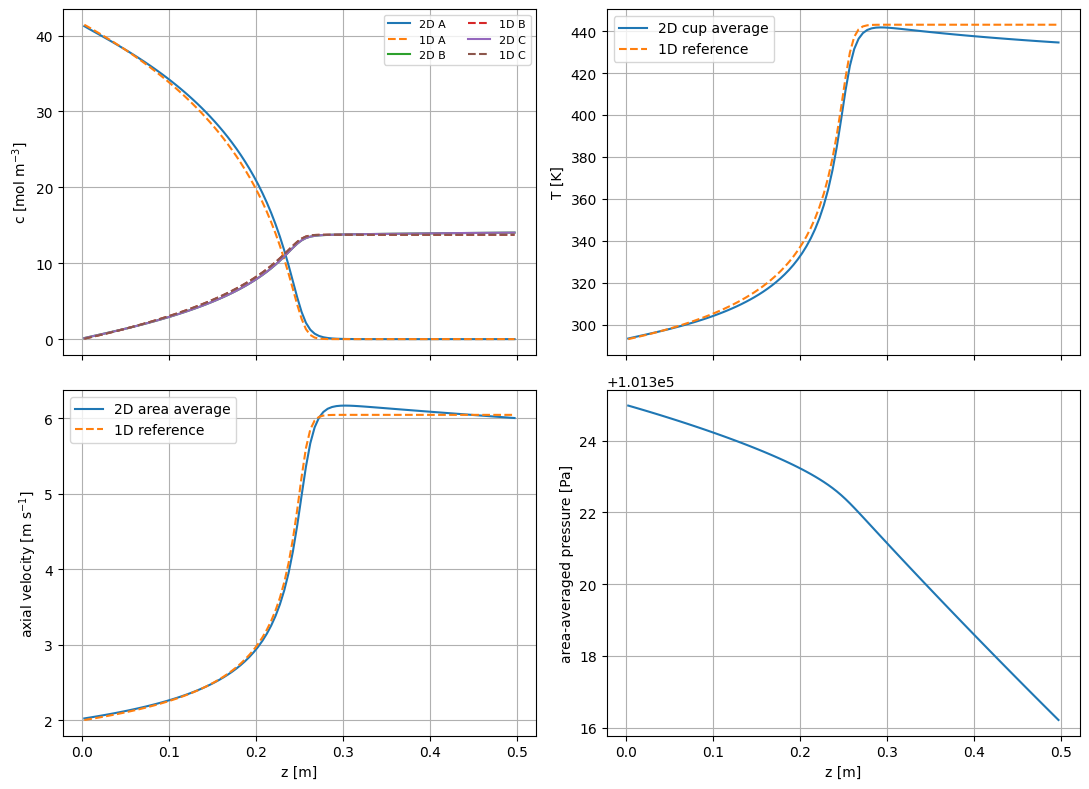

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
species_labels = ["A", "B", "C"]
for i, label in enumerate(species_labels):
    axes[0, 0].plot(model.z_c, c_cup[:, i], label=f"2D {label}")
    axes[0, 0].plot(model.z_c, ref_concentration_c[:, i], "--", label=f"1D {label}")
axes[0, 0].set_ylabel("c [mol m$^{-3}$]")
axes[0, 0].legend(ncol=2, fontsize=8)

axes[0, 1].plot(model.z_c, t_cup, label="2D cup average")
axes[0, 1].plot(model.z_c, ref_temperature_c, "--", label="1D reference")
axes[0, 1].set_ylabel("T [K]")
axes[0, 1].legend()

axes[1, 0].plot(model.z_c, vz_area, label="2D area average")
axes[1, 0].plot(model.z_c, ref_velocity_c, "--", label="1D reference")
axes[1, 0].set_xlabel("z [m]")
axes[1, 0].set_ylabel("axial velocity [m s$^{-1}$]")
axes[1, 0].legend()

axes[1, 1].plot(model.z_c, p_area)
axes[1, 1].set_xlabel("z [m]")
axes[1, 1].set_ylabel("area-averaged pressure [Pa]")

for ax in axes.ravel():
    ax.grid(True)
plt.tight_layout()
plt.show()


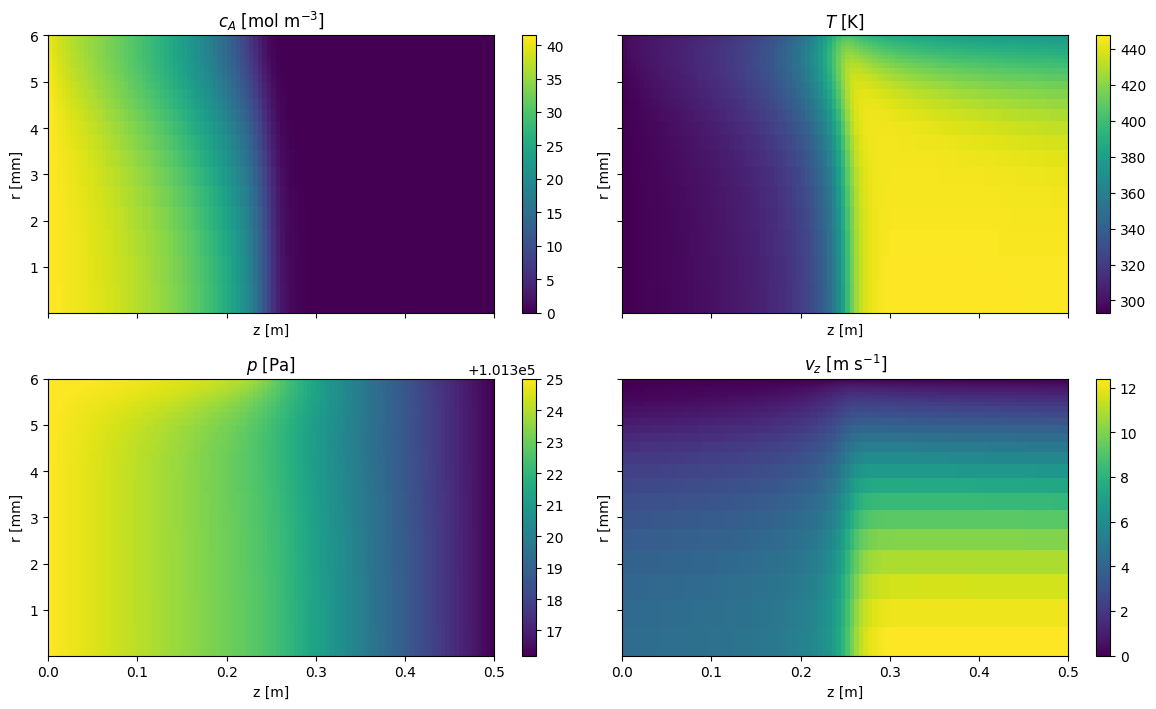

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.2), sharex=True, sharey=True)
mesh_z, mesh_r = np.meshgrid(model.z_c, model.r_c, indexing="ij")

fields = [
    (concentration[..., 0], "$c_A$ [mol m$^{-3}$]"),
    (temperature, "$T$ [K]"),
    (pressure, "$p$ [Pa]"),
    (0.5 * (v_z[:-1, :] + v_z[1:, :]), "$v_z$ [m s$^{-1}$]"),
]

for ax, (field, title) in zip(axes.ravel(), fields):
    pcm = ax.pcolormesh(mesh_z, 1e3 * mesh_r, field, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("z [m]")
    ax.set_ylabel("r [mm]")
    fig.colorbar(pcm, ax=ax)

plt.tight_layout()
plt.show()


## Robustness Notes

Pressure-velocity coupled reactor models are sensitive because pressure affects velocity, velocity affects convection, and convection appears in every species and heat balance. The implementation above uses a few choices that make the example reliable enough for teaching.

**Backflow at the outlet.** If the computed outlet velocity reverses during a Newton iteration, the outlet is no longer an outflow boundary. The upwind boundary condition must switch accordingly. In this notebook, an outlet face uses a zero-gradient condition for outflow and a reservoir value for inflow. This prevents the solver from extrapolating unphysical values into the domain during intermediate Newton steps.

**Pressure equation.** The pressure row is a total molar continuity equation, not the ideal gas law itself. The EOS is still used to compute the total concentration in that pressure row,

$$
c_{\mathrm{tot},p}=p/(RT),
$$

but pressure is solved so that the velocity field satisfies total continuity. If the EOS alone were used as the pressure equation, pressure would enforce density locally but would not directly enforce the flow field required by expansion, reaction, and temperature changes.

**Radial Darcy term.** The radial pressure velocity

$$
v_r=-K_r\partial p/\partial r
$$

is a modeling device that gives the 2D pressure field a controlled radial response. If $K_r$ is too small, radial pressure variations can become unnecessarily large. If $K_r$ is too large, radial pressure becomes an overly strong penalty constraint and the Jacobian becomes stiff. For this notebook, $K_r$ is chosen to keep radial pressure variations small compared with the axial pressure drop without dominating the Newton step.

**Arrhenius coupling.** For an exothermic reaction, the derivative of the Arrhenius factor with respect to temperature can create a strong positive feedback in Newton's method: a hotter trial state increases the rate, which increases heat release, which pushes the trial state hotter again. Here the rate constant is evaluated from the previous time level and held fixed during each Newton solve. The reaction is still implicit in concentration, but the most nonlinear thermal feedback is handled between time steps rather than inside the Jacobian.

**Accumulation term.** The backward-Euler accumulation terms are useful even when the target is a nearly steady profile. With a parabolic velocity profile, cells near the wall have very small axial velocity. In a pure steady solve, those cells may have weak inflow and outflow information, which can leave nearly singular local modes. The accumulation terms give every cell an inventory relative to the previous state and remove those modes.

**Energy equation form.** The full enthalpy balance is conservative and the enthalpy flux should in principle be based on the total molar species fluxes,

$$
\sum_i \mathbf{N}_i C_{p,i}(T-T_\mathrm{ref}),
\qquad \mathbf{N}_i=c_i\mathbf{v}+\mathbf{J}_i.
$$

That form includes diffusive enthalpy transport. In this clean pressure-velocity example, the implemented equation instead uses a cell-centered volumetric heat capacity multiplying $\nabla\cdot(\mathbf{v}T)-T\nabla\cdot\mathbf{v}$, plus Fourier heat conduction. The $\mathbf{v}T$ term is evaluated with upwind/TVD face interpolation. This avoids the checkerboard temperature modes that can appear when central differences are used for convection-dominated heat transport.

The cooled 2D case is intentionally different from the 1D adiabatic reference. Wall cooling and the finite radius create radial temperature and concentration profiles, so the 2D model shows behavior that a 1D plug-flow model cannot represent.
